# Laboratorio 6 - Limpieza y transformación de datos sucios

Fecha: 28 de mayo del 2026

Autor: Martin Lara Olivares

**Objetivo:** Identificar y corregir problemas de calidad en un dataset sucio aplicando técnicas de limpieza como manejo de nulos, duplicados, outliers y validación de datos.

In [3]:
#importar
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

In [5]:
import numpy as np

In [6]:
import seaborn as sns

In [7]:
#cargar dataset sucio
dfSucio = pd.read_csv("../DataSet/dataset_sucio_practica.csv")

In [8]:
dfSucio.shape

(125, 8)

In [9]:
#ver primer anomalía: Datos repetidos

dfSucio.head()



,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [10]:
dfSucio.tail()

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
124,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [11]:
#ver segunda anomalía: Datos atípico

dfSucio.describe()

,id,edad,salario
count,125.000000,110.000000,107.000000
mean,58.200000,43.945455,14093.457944
std,35.906465,47.489803,8825.918852
min,1.000000,-5.000000,-1000.000000
25%,27.000000,22.750000,12000.000000
50%,58.000000,30.000000,15000.000000
75%,89.000000,40.000000,18000.000000
max,120.000000,150.000000,25000.000000


In [12]:
#ver tercer anomalia: Fracturas estructurales

dfSucio [dfSucio["id"].isin([29,55,48])]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
47,48,Mitchell Moses,NaN,heatherclark@green.com,Argentina,18000.0,2025-10-05,Sí
54,55,John Lewis,NaN,rodriguezbrett@yahoo.com,México,-1000.0,2024-07-03,NaN


In [13]:
#ver cuarta anomalia : valores vacíos e inválidos 
dfSucio.head()

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [14]:
#Crear copia del dataset
dfCopy = dfSucio.copy()

In [15]:
#ver la estructura
dfSucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    str    
 2   edad            110 non-null    float64
 3   correo          125 non-null    str    
 4   pais            82 non-null     str    
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    str    
 7   activo          90 non-null     str    
dtypes: float64(2), int64(1), str(5)
memory usage: 7.9 KB


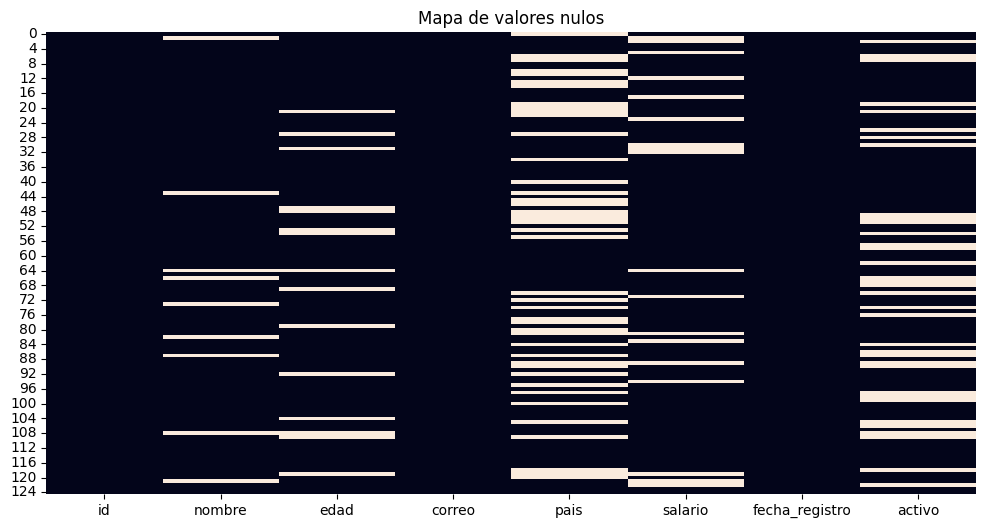

In [16]:
plt.figure(figsize=(12,6))
sns.heatmap( dfSucio.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

In [17]:
# limpiar
# ver los duplicador
dfSucio.duplicated().sum()

np.int64(5)

In [18]:
# borrar los duplicador
dfSucio.drop_duplicates(inplace=True)

In [19]:
# ver que ya no hay  los duplicador
dfSucio.duplicated().sum()

np.int64(0)

In [20]:
# verlas edad raras
dfSucio[(dfSucio["edad"] < 0 ) | (dfSucio["edad"] > 110 )]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí
6,7,Roberto Smith,-5.0,vegasara@yahoo.com,NaN,12000.0,2026-03-31,NaN
7,8,Nicholas Torres,-5.0,arnoldjoe@macias.biz,NaN,12000.0,2026-04-07,NaN
9,10,Angela Richards,-5.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
12,13,Paul Liu,150.0,ilong@gmail.com,España,NaN,2025-11-21,No
16,17,Christopher Klein,-5.0,ericarice@hotmail.com,España,18000.0,2024-09-22,Sí
22,23,Mrs. Diane Carter,150.0,schultzpatrick@mccoy.net,NaN,18000.0,2024-10-31,No
23,24,Vicki Love,-5.0,antonio14@johnson.net,Argentina,NaN,2026-01-24,No
24,25,Matthew Porter,-5.0,hansoncameron@yahoo.com,Argentina,12000.0,2025-11-17,No


In [21]:
# volver nan las edades raras
dfSucio.loc[(dfSucio["edad"] < 0 ) | (dfSucio["edad"] > 110) , "edad"] = np.nan

In [22]:
#calcular la mediana
mediana_edad = dfSucio["edad"].median()

In [23]:
# ver la mediana
mediana_edad 

np.float64(30.0)

In [24]:
#llenar con la mediana
dfSucio["edad"] = dfSucio["edad"].fillna(mediana_edad)

In [25]:
dfSucio["edad"].describe()

count    120.000000
mean      30.325000
std        4.745918
min       22.000000
25%       30.000000
50%       30.000000
75%       31.250000
max       40.000000
Name: edad, dtype: float64

In [26]:
# solucionar anomalia de salarios negativos
# ver los datos anomalos
dfSucio[ dfSucio["salario"] < 0 ]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
9,10,Angela Richards,30.0,rubiogabrielle@yahoo.com,Argentina,-1000.0,2025-09-22,Sí
11,12,Daniel Wright,25.0,melissamaxwell@gmail.com,NaN,-1000.0,2024-12-20,Sí
20,21,Marc Miller DDS,30.0,ccalderon@campbell-carter.com,NaN,-1000.0,2024-06-25,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,-1000.0,2025-05-05,NaN
26,27,Mary Miranda,40.0,brendaglenn@gmail.com,Argentina,-1000.0,2025-06-01,NaN
27,28,John Taylor,30.0,jonesashley@hotmail.com,NaN,-1000.0,2025-08-02,No
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
37,38,Brian Sherman,30.0,brianna61@yahoo.com,Argentina,-1000.0,2024-09-17,Sí
41,42,Patricia Morrison,30.0,uweiss@yahoo.com,Argentina,-1000.0,2026-03-10,No
44,45,John Estrada,35.0,nichole26@hotmail.com,Argentina,-1000.0,2025-12-12,Sí


In [27]:
# volver nan los salarios raros
dfSucio.loc[(dfSucio["salario"] < 0 ) , "salario"] = np.nan

In [28]:
#calcular la mediana
mediana_salario = dfSucio["salario"].median()

In [29]:
# ver el salario mediano
mediana_salario 

np.float64(15000.0)

In [30]:
#llenar con la mediana
dfSucio["salario"] = dfSucio["salario"].fillna(mediana_salario)

In [31]:
# verificar
dfSucio["salario"].describe()

count      120.000000
mean     16741.666667
std       4401.099621
min      12000.000000
25%      15000.000000
50%      15000.000000
75%      18000.000000
max      25000.000000
Name: salario, dtype: float64

In [32]:
# corregir correos no validos

dfSucio[~dfSucio["correo"] .str.contains("@",na = False)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,30.0,correo_invalido,México,25000.0,2025-03-28,Sí
18,19,Nicholas Curry,35.0,correo_invalido,México,12000.0,2025-11-22,Sí
21,22,Carrie Griffith,30.0,correo_invalido,NaN,15000.0,2025-05-05,NaN
30,31,Mrs. Sara Johnson,35.0,correo_invalido,Argentina,15000.0,2026-03-07,NaN
40,41,Cynthia Arnold,30.0,correo_invalido,NaN,25000.0,2024-11-03,No
65,66,Michael Lopez,40.0,correo_invalido,España,15000.0,2025-12-01,No
78,79,Charles Page,25.0,correo_invalido,NaN,15000.0,2025-09-01,No
87,88,NaN,22.0,correo_invalido,NaN,12000.0,2025-03-07,NaN
88,89,Erika Bernard,30.0,correo_invalido,Argentina,12000.0,2024-11-16,Sí


In [33]:
# correos no validos

correo_invalido = ~dfSucio["correo"] .str.contains("@",na = False)
dfSucio.loc[ correo_invalido , "correo"] = pd.NA

In [34]:
dfSucio[~dfSucio["correo"] .str.contains("@",na = False)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,NaN,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,30.0,NaN,México,25000.0,2025-03-28,Sí
18,19,Nicholas Curry,35.0,NaN,México,12000.0,2025-11-22,Sí
21,22,Carrie Griffith,30.0,NaN,NaN,15000.0,2025-05-05,NaN
30,31,Mrs. Sara Johnson,35.0,NaN,Argentina,15000.0,2026-03-07,NaN
40,41,Cynthia Arnold,30.0,NaN,NaN,25000.0,2024-11-03,No
65,66,Michael Lopez,40.0,NaN,España,15000.0,2025-12-01,No
78,79,Charles Page,25.0,NaN,NaN,15000.0,2025-09-01,No
87,88,NaN,22.0,NaN,NaN,12000.0,2025-03-07,NaN
88,89,Erika Bernard,30.0,NaN,Argentina,12000.0,2024-11-16,Sí


In [35]:
# corregir paises no aseignado
dfSucio["pais"].isnull().sum()

np.int64(42)

In [36]:
#calcular la moda del pais
moda_pais = dfSucio["pais"].mode()[0]

In [37]:
moda_pais

'Argentina'

In [38]:
#llenar con la moda
dfSucio["pais"] = dfSucio["pais"].fillna(moda_pais)

In [39]:
#verificar
dfSucio["pais"].isnull().sum()

np.int64(0)

In [40]:
# ver tipos de datos
dfSucio.dtypes

id                  int64
nombre                str
edad              float64
correo                str
pais                  str
salario           float64
fecha_registro        str
activo                str
dtype: object

In [41]:
# convertimos fecha a date time
dfSucio["fecha_registro"] = pd.to_datetime(dfSucio["fecha_registro"])

In [42]:
dfSucio["fecha_registro"].dt.year

0      2026
1      2026
2      2026
3      2025
4      2025
       ... 
115    2024
116    2024
117    2026
118    2025
119    2026
Name: fecha_registro, Length: 120, dtype: int32

In [43]:
# categorizar e campo activo
dfSucio["activo"].value_counts(dropna = False)

activo
Sí     47
No     39
NaN    34
Name: count, dtype: int64

In [44]:
# pasar el campo a activo todos los nan
dfSucio["activo"] = dfSucio["activo"].fillna("Sí")

In [45]:
# verificar
dfSucio["activo"].value_counts(dropna = False)

activo
Sí    81
No    39
Name: count, dtype: int64

In [48]:
# convertir a binario
dfSucio["activo"] = dfSucio["activo"].map({
	"Sí":1, 
	"No":0
	})

In [49]:
# verificar
dfSucio["activo"].value_counts(dropna = False)

activo
1    81
0    39
Name: count, dtype: int64

In [54]:
(dfSucio.isnull().sum()/len (dfSucio) * 100)

id                 0.000000
nombre             6.666667
edad               0.000000
correo            10.000000
pais               0.000000
salario            0.000000
fecha_registro     0.000000
activo             0.000000
dtype: float64


# conclusiones
Durante la practica se identificaron y corrigieron los siguientes problemas

1. Datos repetidos, se eliminaron los datos duplicados
2. Datos atípicos, se corrigieron los datos no validos
3. Se revisaron y corrigieron tipos de datos
4. Se categorizaron datos que se consideran necesarios